## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Peloponnese'

In [3]:
years = range(2009, 2024)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2009 | (42780, 102)
Year: 2010 | (42780, 102)
Year: 2011 | (42780, 102)
Year: 2012 | (42780, 102)
Year: 2013 | (42780, 102)
Year: 2014 | (42780, 102)
Year: 2015 | (42780, 102)
Year: 2016 | (42780, 102)
Year: 2017 | (42780, 102)
Year: 2018 | (42780, 102)
Year: 2019 | (42780, 102)
Year: 2020 | (42780, 102)
Year: 2021 | (42780, 102)
Year: 2022 | (42780, 102)
Year: 2023 | (42780, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.59494,37.06563,2,3,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.026,14.962,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN
1,0,2009-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.59494,37.06563,2,3,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.234,13.066,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN
2,0,2009-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.59494,37.06563,2,3,1,2009,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.530,18.378,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN
3,0,2009-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.59494,37.06563,2,3,1,2009,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.046,24.998,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN
4,0,2009-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.59494,37.06563,2,3,1,2009,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.978,31.830,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

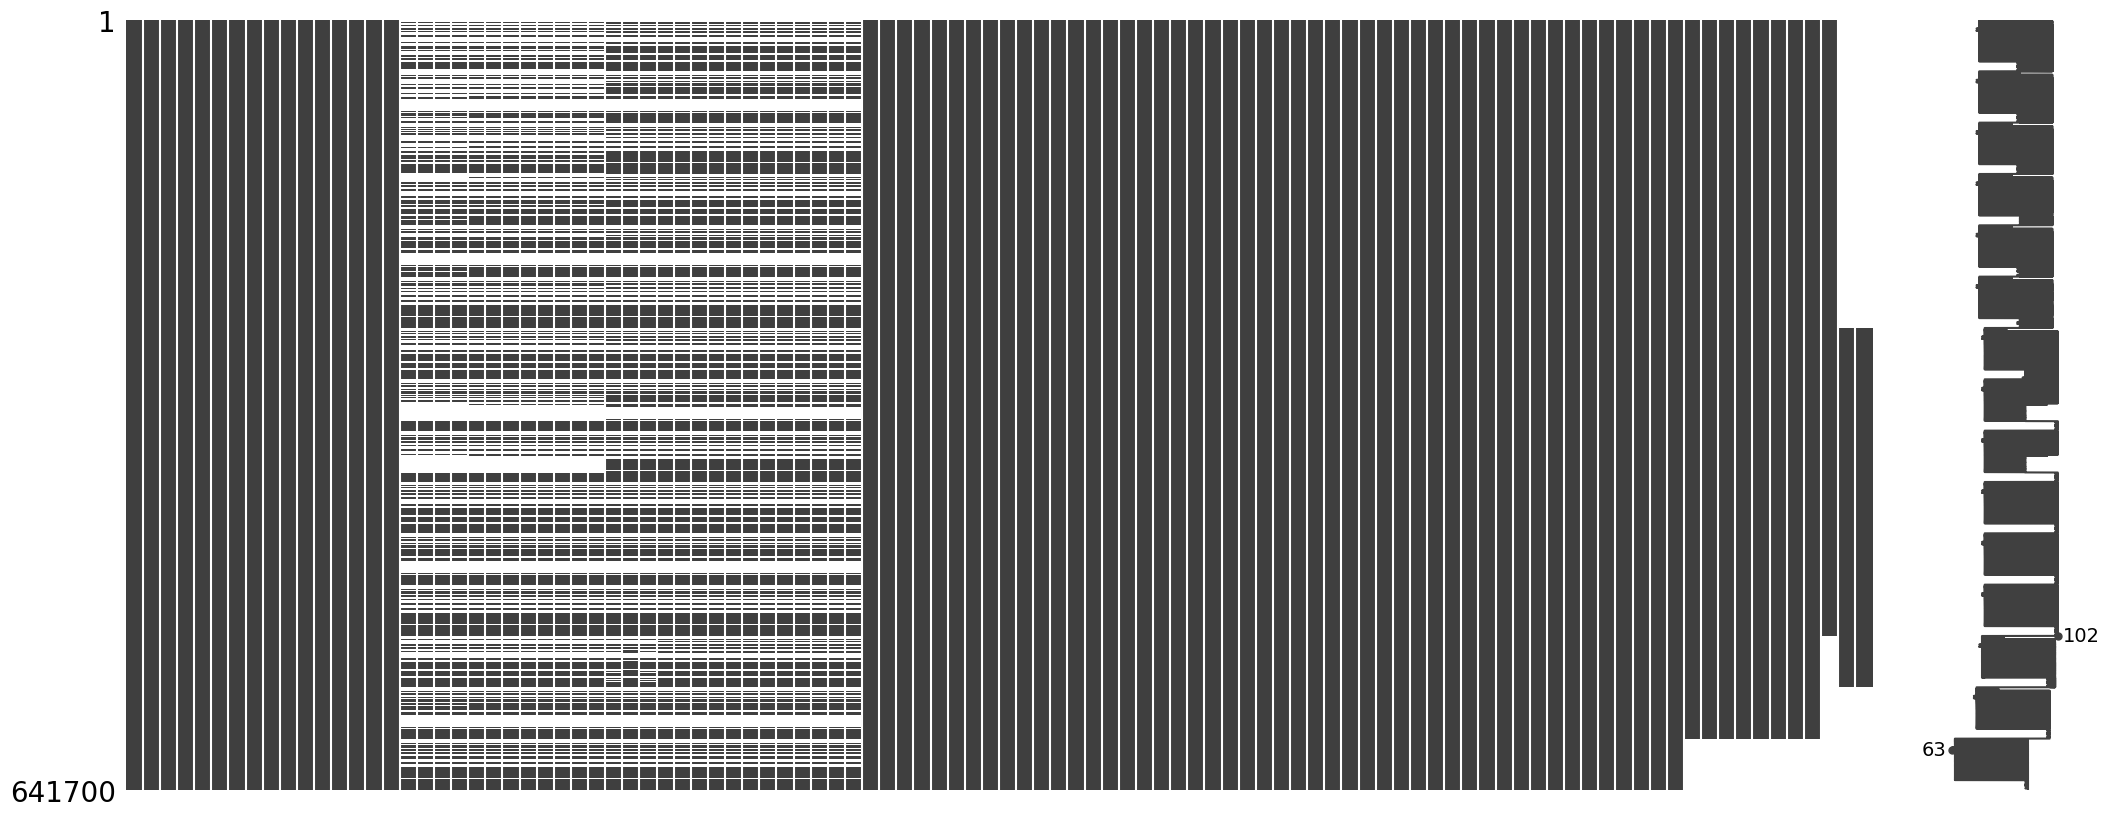

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,49.5682
17,ndmi,49.5683
18,ndwi,49.5682
19,ndbi,49.5683
20,ndvi_mean,48.6763
...,...,...
97,F_Y_GE65,6.6667
98,F_TOTAL,6.6667
99,MIO_EUR,20.0000
100,L_TOTAL,53.3333


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['NUTS1_NAME', 'NUTS1_ID', 'rainfall_acc']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2009-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,0,21.59494,37.06563,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.026,14.962,0.000000,0.000000,0.000000,0.000000,0.000000,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN,2,3,1
1,2009-02,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,0,21.59494,37.06563,2,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.234,13.066,0.000000,0.000000,0.000000,0.000000,0.000000,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN,2,3,1
2,2009-03,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,0,21.59494,37.06563,3,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.530,18.378,0.000000,0.000000,0.000000,0.000000,0.000000,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN,2,3,1
3,2009-04,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,0,21.59494,37.06563,4,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.046,24.998,0.000000,0.000000,0.000000,0.000000,0.000000,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN,2,3,1
4,2009-05,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,0,21.59494,37.06563,5,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.978,31.830,0.000000,0.000000,0.000000,0.000000,0.000000,16.375000,18.750000,42.613636,810.197787,40.0,-4.0,44.0,6.833333,6.833333,26.333333,6.833333,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,94,30,94.0,30,94,10,10,1,6,6,2,0,17313.0,82233.0,27717.0,127263.0,16712.0,76246.0,32321.0,125279.0,3836.48,NaN,NaN,2,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2010 | Month: 1
Year: 2010 | Month: 2
Year: 2010 | Month: 3
Year: 2010 | Month: 4
Year: 2010 | Month: 5
Year: 2010 | Month: 6
Year: 2010 | Month: 7
Year: 2010 | Month: 8
Year: 2010 | Month: 9
Year: 2010 | Month: 10
Year: 2010 | Month: 11
Year: 2010 | Month: 12
Year: 2011 | Month: 1
Year: 2011 | Month: 2
Year: 2011 | Month: 3
Year: 2011 | Month: 4
Year: 2011 | Month: 5
Year: 2011 | Month: 6
Year: 2011 | Month: 7
Year: 2011 | Month: 8
Year: 2011 | Month: 9
Year: 2011 | Month: 10
Year: 2011 | Month: 11
Year: 2011 | Month: 12
Year: 2012 | Month: 1
Year: 2012 | Month: 2
Year: 2012 | Month: 3
Year: 2012 | Month: 4
Year: 2012 | Month: 5
Year: 2012 | Month: 6
Year: 2012 | Month: 7
Year: 2012 | Month: 8
Year: 2012 | Month: 9
Year: 2012 | Month: 10
Year: 2012 | Month: 11
Year: 2012 | Month: 12
Year: 2013 | Month: 1
Year: 2013 | Month: 2
Year: 2013 | Month: 3
Year: 2013 | Month: 4
Year: 2013 | Month: 5
Year: 2013 | Month: 6
Year: 2013 | Month: 7
Year: 2013 | Month: 8
Year: 2013 | Month: 9
Y

In [19]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2017)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
342240,2017-01,"λακωνια, μεσσηνια",0,21.59494,37.06563,1,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.094,11.486,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,84,30,84.0,30,84,10,10,1,6,6,2,0,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
342241,2017-02,"λακωνια, μεσσηνια",0,21.59494,37.06563,2,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.130,17.534,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,84,30,84.0,30,84,10,10,1,6,6,2,0,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
342242,2017-03,"λακωνια, μεσσηνια",0,21.59494,37.06563,3,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.958,22.702,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,84,30,84.0,30,84,10,10,1,6,6,2,0,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
342243,2017-04,"λακωνια, μεσσηνια",0,21.59494,37.06563,4,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.442,25.774,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,84,30,84.0,30,84,10,10,1,6,6,2,0,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
342244,2017-05,"λακωνια, μεσσηνια",0,21.59494,37.06563,5,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.090,29.514,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,84,30,84.0,30,84,10,10,1,6,6,2,0,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
342245,2017-06,"λακωνια, μεσσηνια",0,21.59494,37.06563,6,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.766,36.890,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,31,84,30,84.0,30,84,10,10,1,6,6,2,0,16822.0,78987.0,29757.0,125566.0,16397.0,7

In [20]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2018)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
342240,0,EL65,EL653,τριφυλιας,2018,1,21.59494,37.06563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.250,14.058,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,30,30,10,10,1,6,6,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
345805,0,EL65,EL653,τριφυλιας,2018,2,21.59494,37.06563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.894,14.418,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,30,30,10,10,1,6,6,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
349370,0,EL65,EL653,τριφυλιας,2018,3,21.59494,37.06563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.246,13.950,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,30,30,10,10,1,6,6,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
352935,0,EL65,EL653,τριφυλιας,2018,4,21.59494,37.06563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.710,19.262,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,30,30,10,10,1,6,6,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
356500,0,EL65,EL653,τριφυλιας,2018,5,21.59494,37.06563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.870,29.830,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,30,30,10,10,1,6,6,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
360065,0,EL65,EL653,τριφυλιας,2018,6,21.59494,37.06563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.134,31.042,0.0,0.0,0.0,0.0,0.0,16.791667,18.75,41.666667,842.738591,41.0,-4.0,45.0,8.0,8.0,27.333333,6.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,30,30,10,10,1,6,6,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.0,7.495073,16822.0,78987.0,29757.0,125566.0,16397.0,75517.0,32654.0,124568.0,3112.33,3065.0,3506.0,2,3,1
363630,0,EL65,EL653,τριφυλιας,2018,7,21.59494,37.06563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

<Axes: >

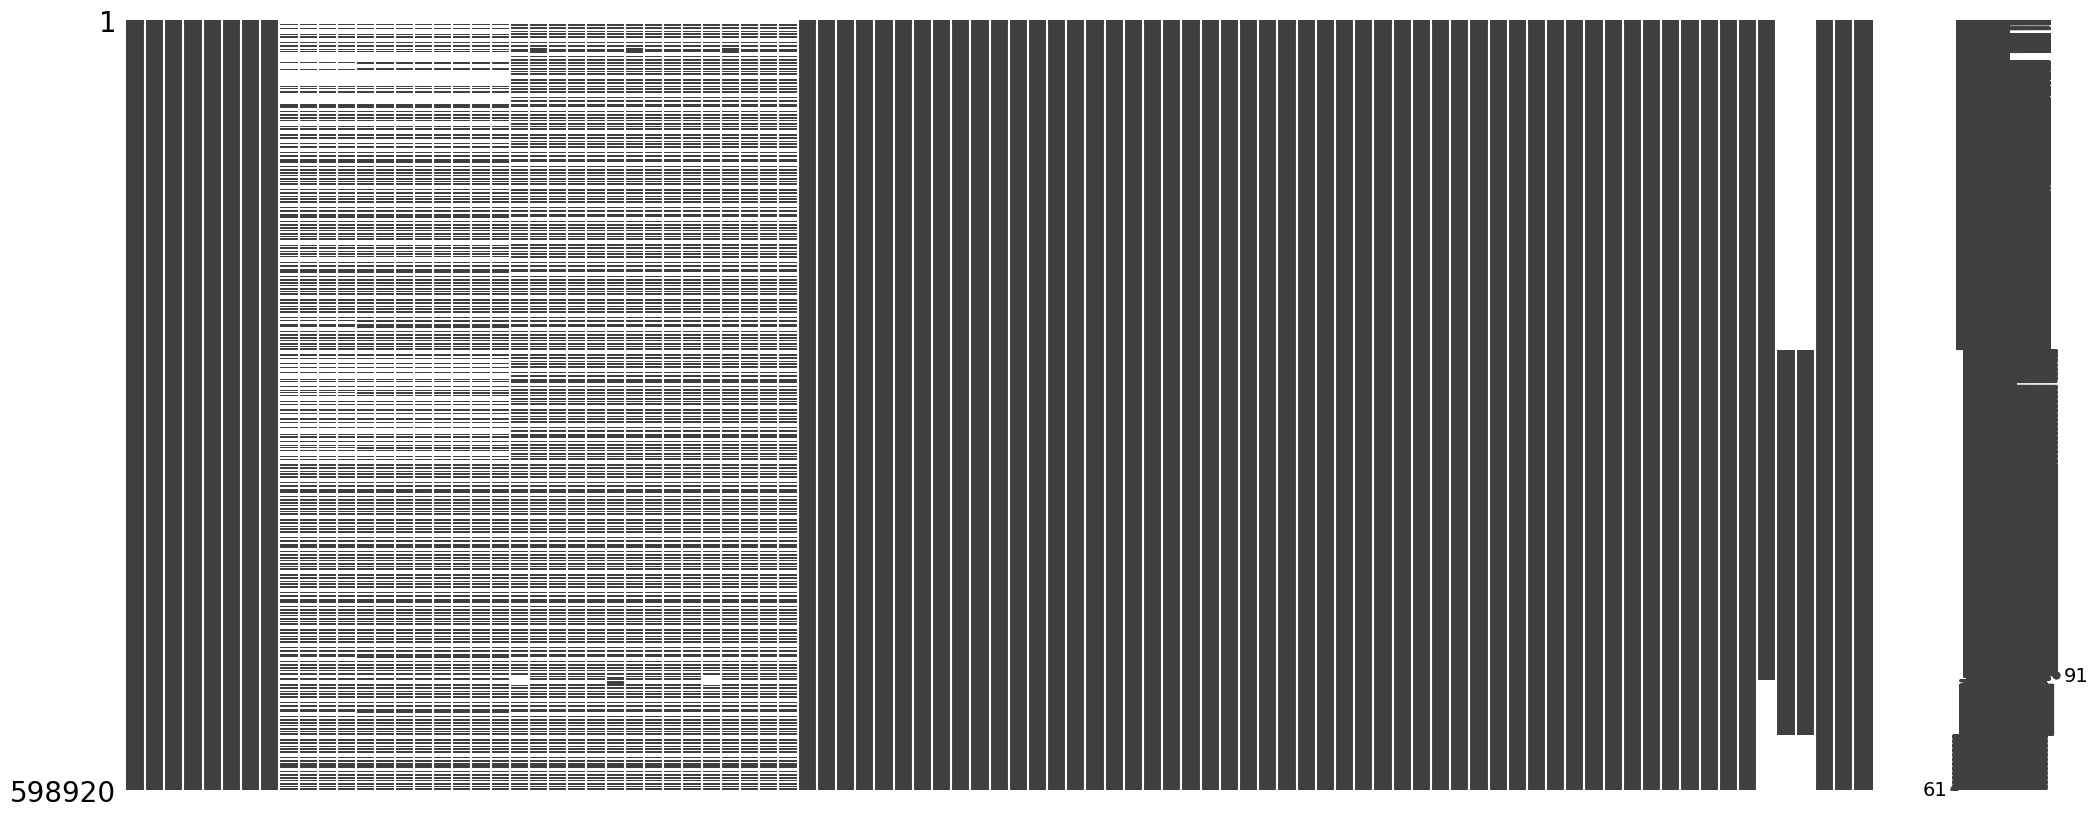

In [21]:
missingno.matrix(dataset_operational)

In [22]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,49.0864
9,ndmi,49.0865
10,ndwi,49.0864
11,ndbi,49.0865
12,ndvi_mean,48.2233
...,...,...
33,lst_mar_mean,41.3444
34,lst_apr_mean,41.3444
85,mio_eur,14.2857
86,l_total,50.0000


In [23]:
# dataset_monthly.cases.sum()

In [24]:
# dataset_operational.cases.sum()

In [25]:
years = dataset_operational.year.unique().tolist()

In [26]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)